In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts

In [ ]:
df = pd.read_csv('kc_house_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df_new = df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'grade', 'view', 'condition']]

In [ ]:
df_new.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,grade,view,condition
0,221900.0,3,1.00,1180,1.0,0,7,0,3
1,538000.0,3,2.25,2570,2.0,0,7,0,3
2,180000.0,2,1.00,770,1.0,0,6,0,3
3,604000.0,4,3.00,1960,1.0,0,7,0,5
4,510000.0,3,2.00,1680,1.0,0,8,0,3


# Очищение выборки от выбросов с помощью межвакртильного размаха

In [ ]:
df_new.describe()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,grade,view,condition
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.494309,0.007542,7.656873,0.234303,3.409430
std,3.671272e+05,0.930062,0.770163,918.440897,0.539989,0.086517,1.175459,0.766318,0.650743
min,7.500000e+04,0.000000,0.000000,290.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,1.000000,0.000000,7.000000,0.000000,3.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,1.500000,0.000000,7.000000,0.000000,3.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,2.000000,0.000000,8.000000,0.000000,4.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,3.500000,1.000000,13.000000,4.000000,5.000000


### Чистка выбросов по переменной *price* для датасета *df_new*

In [ ]:
Q1_price = df_new['price'].quantile(0.25)
Q3_price = df_new['price'].quantile(0.75)
print(Q1_price, Q3_price)

321950.0 645000.0


In [ ]:
IQR_price =  Q3_price-Q1_price

In [ ]:
IQR_price

np.float64(323050.0)

In [ ]:
lower_bound_pr = Q1_price - 1.5 * IQR_price
upper_bound_pr = Q3_price + 1.5 * IQR_price
print(lower_bound_pr, upper_bound_pr)

-162625.0 1129575.0


In [ ]:
df_clean = df_new[(df_new['price'] >= lower_bound_pr) & (df_new['price'] <= upper_bound_pr)]

In [ ]:
print(len(df_clean), len(df_new['price']))

20467 21613


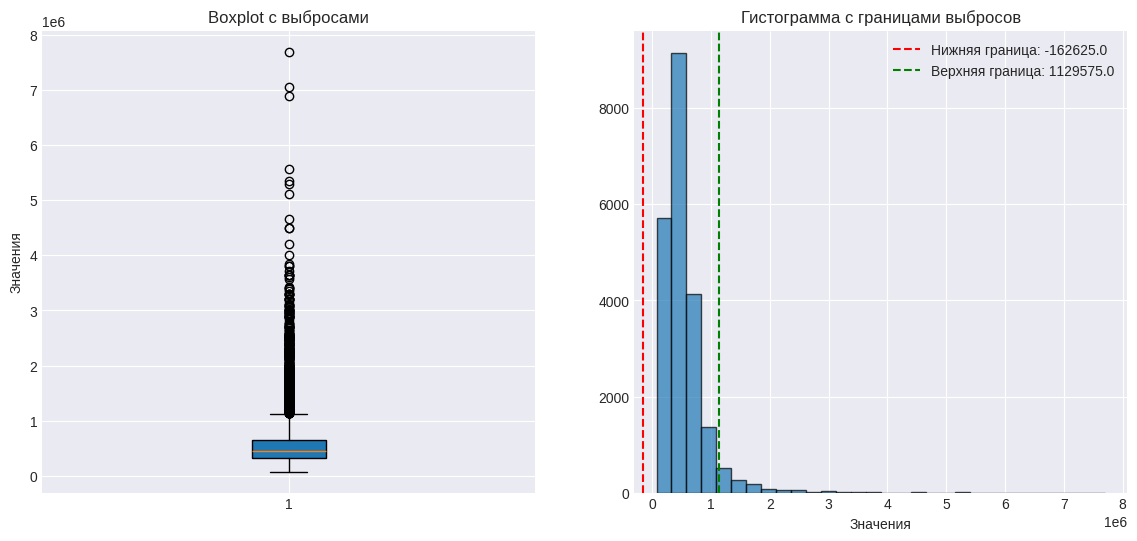

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.boxplot(df_new['price'], vert=True, patch_artist=True)
ax1.set_title("Boxplot с выбросами")
ax1.set_ylabel("Значения")

ax2.hist(df_new['price'], bins=30, alpha=0.7, edgecolor='black')
ax2.axvline(lower_bound_pr, color='red', linestyle='--', label=f'Нижняя граница: {lower_bound_pr:.1f}')
ax2.axvline(upper_bound_pr, color='green', linestyle='--', label=f'Верхняя граница: {upper_bound_pr:.1f}')
ax2.set_title("Гистограмма с границами выбросов")
ax2.set_xlabel("Значения")
ax2.legend()

In [ ]:
df_clean.describe()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,grade,view,condition
count,2.046700e+04,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000
mean,4.769846e+05,3.329750,2.051632,1975.558167,1.476035,0.002980,7.530561,0.172668,3.406361
std,2.083713e+05,0.912885,0.711906,774.833460,0.537033,0.054513,1.039192,0.640950,0.647228
min,7.500000e+04,0.000000,0.000000,290.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,3.150000e+05,3.000000,1.500000,1400.000000,1.000000,0.000000,7.000000,0.000000,3.000000
50%,4.375000e+05,3.000000,2.000000,1860.000000,1.000000,0.000000,7.000000,0.000000,3.000000
75%,6.000000e+05,4.000000,2.500000,2431.000000,2.000000,0.000000,8.000000,0.000000,4.000000
max,1.127500e+06,33.000000,7.500000,7480.000000,3.500000,1.000000,12.000000,4.000000,5.000000


# Корреляционная матрица

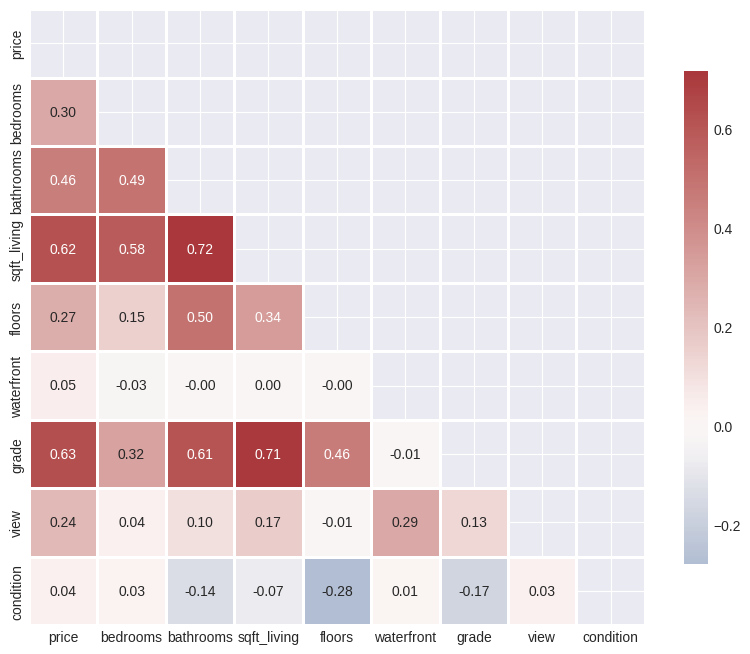

In [ ]:
corr_matrix = df_clean.corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='vlag',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
plt.savefig('heatmap.png', bbox_inches='tight')

# Визуальный анализ

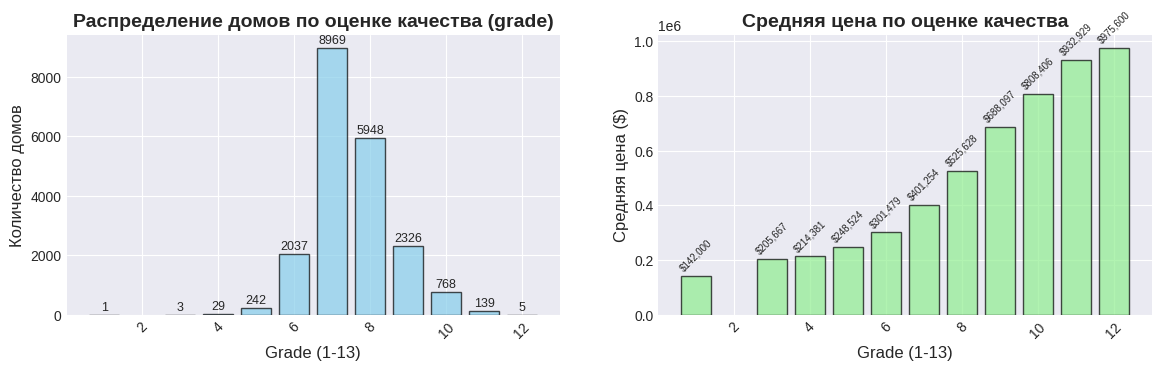

In [ ]:
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-darkgrid')

# Создаем данные для графика
grade_counts = df_clean['grade'].value_counts().sort_index()
grade_prices = df_clean.groupby('grade')['price'].mean()

# График 1: Распределение grade
plt.subplot(2, 2, 1)
bars1 = plt.bar(grade_counts.index, grade_counts.values, alpha=0.7, edgecolor='black', color='skyblue')
plt.title('Распределение домов по оценке качества (grade)', fontweight='bold', fontsize=14)
plt.xlabel('Grade (1-13)', fontsize=12)
plt.ylabel('Количество домов', fontsize=12)
plt.xticks(rotation=45)

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

# График 2: Средняя цена по grade
plt.subplot(2, 2, 2)
bars2 = plt.bar(grade_prices.index, grade_prices.values, alpha=0.7, edgecolor='black', color='lightgreen')
plt.title('Средняя цена по оценке качества', fontweight='bold', fontsize=14)
plt.xlabel('Grade (1-13)', fontsize=12)
plt.ylabel('Средняя цена ($)', fontsize=12)
plt.xticks(rotation=45)

# Добавляем значения
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=7, rotation=45)

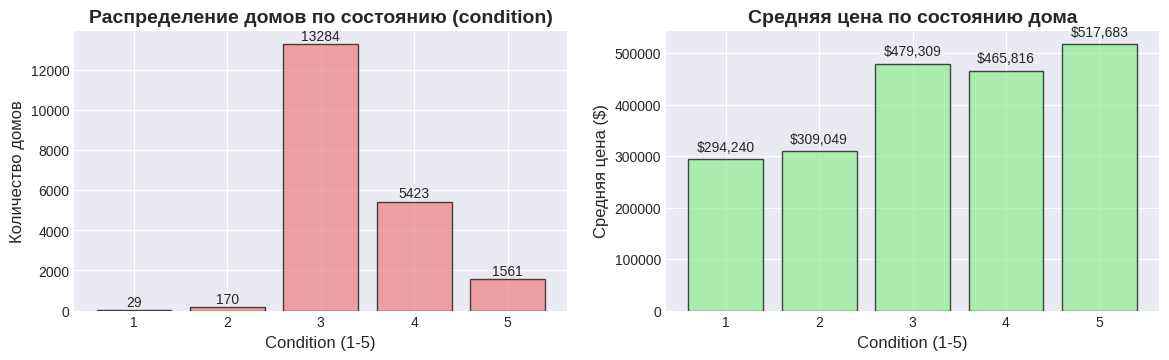

In [ ]:
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-darkgrid')

# Данные
condition_counts = df_clean['condition'].value_counts().sort_index()
condition_prices = df_clean.groupby('condition')['price'].mean()

# График 1: Распределение
plt.subplot(2, 2, 1)
bars1 = plt.bar(condition_counts.index, condition_counts.values, alpha=0.7, edgecolor='black', color='lightcoral')
plt.title('Распределение домов по состоянию (condition)', fontweight='bold', fontsize=14)
plt.xlabel('Condition (1-5)', fontsize=12)
plt.ylabel('Количество домов', fontsize=12)
plt.xticks(rotation=0)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# График 2: Средняя цена
plt.subplot(2, 2, 2)
bars2 = plt.bar(condition_prices.index, condition_prices.values, alpha=0.7, edgecolor='black', color='lightgreen')
plt.title('Средняя цена по состоянию дома', fontweight='bold', fontsize=14)
plt.xlabel('Condition (1-5)', fontsize=12)
plt.ylabel('Средняя цена ($)', fontsize=12)
plt.xticks(rotation=0)

for i, (cond, price) in enumerate(condition_prices.items()):
    plt.text(cond, price + 10000, f'${price:,.0f}',
             ha='center', va='bottom', fontsize=10, rotation=0)

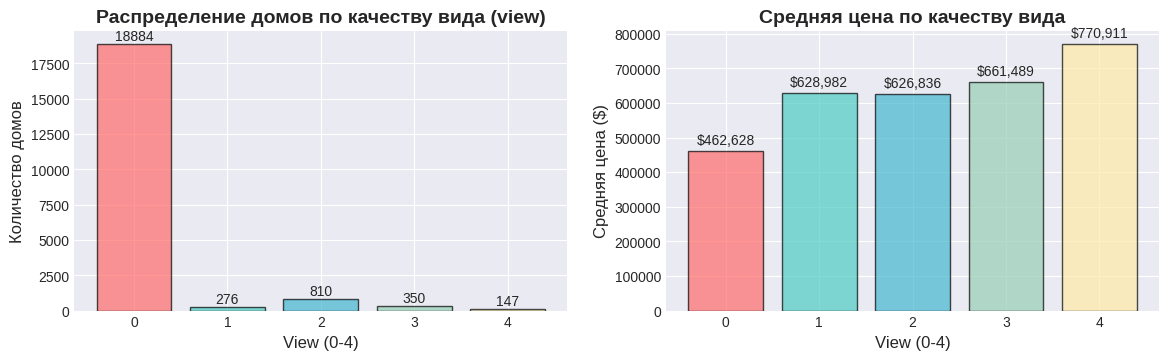

In [ ]:
# Настройки
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-darkgrid')

# Данные
view_counts = df_clean['view'].value_counts().sort_index()
view_prices = df_clean.groupby('view')['price'].mean()

# График 1: Распределение
plt.subplot(2, 2, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars1 = plt.bar(view_counts.index, view_counts.values, alpha=0.7, edgecolor='black', color=colors)
plt.title('Распределение домов по качеству вида (view)', fontweight='bold', fontsize=14)
plt.xlabel('View (0-4)', fontsize=12)
plt.ylabel('Количество домов', fontsize=12)
plt.xticks(rotation=0)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# График 2: Средняя цена
plt.subplot(2, 2, 2)
bars2 = plt.bar(view_prices.index, view_prices.values, alpha=0.7, edgecolor='black', color=colors)
plt.title('Средняя цена по качеству вида', fontweight='bold', fontsize=14)
plt.xlabel('View (0-4)', fontsize=12)
plt.ylabel('Средняя цена ($)', fontsize=12)
plt.xticks(rotation=0)

for i, (view, price) in enumerate(view_prices.items()):
    plt.text(view, price + 10000, f'${price:,.0f}',
             ha='center', va='bottom', fontsize=10, rotation=0)

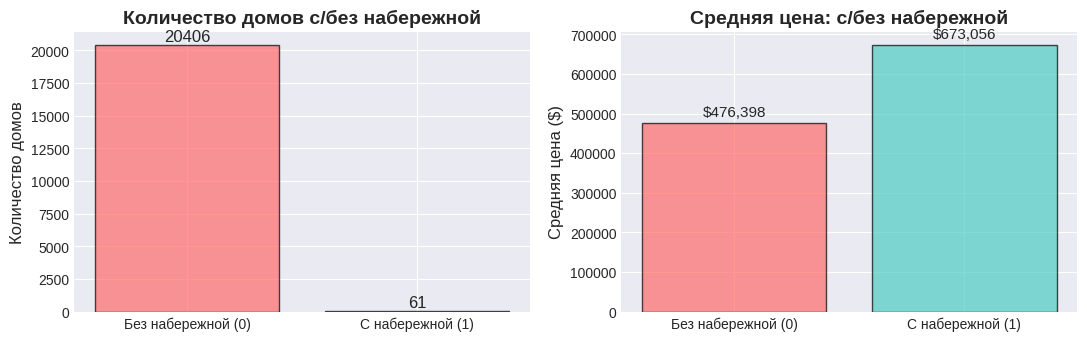

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки
plt.figure(figsize=(20, 8))
plt.style.use('seaborn-v0_8-darkgrid')

# Данные
waterfront_counts = df_clean['waterfront'].value_counts()
waterfront_labels = ['Без набережной (0)', 'С набережной (1)']
plt.subplot(2, 3, 2)
bars1 = plt.bar(waterfront_labels, waterfront_counts.values, alpha=0.7, edgecolor='black', color=colors)
plt.title('Количество домов с/без набережной', fontweight='bold', fontsize=14)
plt.ylabel('Количество домов', fontsize=12)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

# График 3: Средняя цена
plt.subplot(2, 3, 3)
waterfront_prices = df_clean.groupby('waterfront')['price'].mean()
bars2 = plt.bar(waterfront_labels, waterfront_prices.values, alpha=0.7, edgecolor='black', color=colors)
plt.title('Средняя цена: с/без набережной', fontweight='bold', fontsize=14)
plt.ylabel('Средняя цена ($)', fontsize=12)

for i, (label, price) in enumerate(zip(waterfront_labels, waterfront_prices.values)):
    plt.text(i, price + 10000, f'${price:,.0f}',
             ha='center', va='bottom', fontsize=11, rotation=0)

# Выбор спецификации модели, проверка гипотез и оценка модели

Сначала разделим соответствующим образом параметры модели на зависимую и независимые (объясняющие) переменные. Возьмем за бейзлайн обычную линейную спецификацию

In [ ]:
y=df_clean['price']
X=df_clean.drop('price', axis=1)
X=sm.add_constant(X)
model=sm.OLS(y, X).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     2516.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:03:12   Log-Likelihood:            -2.7269e+05
No. Observations:               20467   AIC:                         5.454e+05
Df Residuals:                   20458   BIC:                         5.455e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -4.361e+05   1.17e+04    -37.391      

Как можно наблюдать на результатах, все коэффициента стат. значимы, а F-статистика крайне велика (p_value ниже чем alpha=0.01).
Теперь посмотрим на полулогарифмическую спецификацию

In [ ]:
y_log=np.log(df_clean['price'])
model_log=sm.OLS(y_log, X).fit()

In [ ]:
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     2274.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:03:12   Log-Likelihood:                -6005.8
No. Observations:               20467   AIC:                         1.203e+04
Df Residuals:                   20458   BIC:                         1.210e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          11.0096      0.026    430.295      

Можем наблюдать, что у данной спецификации R2 чуть хуже, чем в бейзланйе, при этом bathrooms перестал быть стат. значимым. На всякий случай проведем тест Зарембки на предмет того, какая модель лучше нам подойдет

In [ ]:
y_gmean=sts.gmean(y)

In [ ]:
y_new=y/y_gmean

In [ ]:
y_new_base=y_new
y_new_log=np.log(y_new)
model_new_base=sm.OLS(y_new_base, X).fit()
model_new_log=sm.OLS(y_new_log, X).fit()

In [ ]:
chi_stat=20467/2*(abs(np.log(np.sum(model_new_base.resid)**2/np.sum(model_new_log.resid)**2)))

In [ ]:
chi_stat

np.float64(1788.3350783973779)

Как можем заметить, статистика (которая многократно больше, чем хи-квадрат с 1 степенью свободы) указывает нам, что линейная спецификация точно будет лучше для дальнейшего анализа и моделирования.

Далее проверим наши пременные на коллинеарность с помощью VIF (variance inflation factor)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

       feature         VIF
0        const  127.196276
1     bedrooms    1.630285
2    bathrooms    2.546134
3  sqft_living    3.344776
4       floors    1.523137
5   waterfront    1.100160
6        grade    2.336324
7         view    1.146512
8    condition    1.098098


В документации самой функции указывается, что при превышении значения VIF, равному пяти, стоит задуматься о возможной коллинеарности. К нашему счастью, у объясняющих переменных с этим все в порядке.
После проверок останавлиемся уже точно на линейной спецификации для проверки дальнейших гипотез

# Проверка гипотез

Гипотеза 1: дома, расположенные рядом с видом на море/океан имеют существенную прибавку к своей стоимости, т.е. коэффициент waterfront положителен и большой. Проверим это при помощи summary из statsmodels

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     2516.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:40:29   Log-Likelihood:            -2.7269e+05
No. Observations:               20467   AIC:                         5.454e+05
Df Residuals:                   20458   BIC:                         5.455e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -4.361e+05   1.17e+04    -37.391      

Как можно наблюдать, коэфф. при waterfront действительно положительный и имеет довольно сильный вклад в стоимость недвижимости. Значит, в нашем случае гипотеза подтверждается

Гипотеза 2: из-за большей неликвидности недвижимость, которая имеет довольно плохое значение grade, будет более выражено зависеть от собственного состояния (condition), чем дома, grade которых средний и выше. В источнике напрямую не указано, что точно относить к плохому, среднему и отличному грейду, поэтому предположим, что это будут дома, значения переменной которых будут 6 и ниже (переменная принимает значения от 1 до 13, т.е. берем середину). Для соответствующей проверки разделим наш сэмпл на два: один, где grade 6 и ниже, и другой, где он выше 6.

In [ ]:
df_grade_below_avg=df_clean[df['grade']<=6]
df_grade_above_avg=df_clean[df['grade']>6]

/tmp/ipython-input-3334437832.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_grade_below_avg=df_clean[df['grade']<=6]
/tmp/ipython-input-3334437832.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_grade_above_avg=df_clean[df['grade']>6]


In [ ]:
y_gr_below_avg=df_grade_below_avg['price']
y_gr_above_avg=df_grade_above_avg['price']
X_gr_below_avg=df_grade_below_avg.drop('price', axis=1)
X_gr_below_avg=sm.add_constant(X_gr_below_avg)
X_gr_above_avg=df_grade_above_avg.drop('price', axis=1)
X_gr_above_avg=sm.add_constant(X_gr_above_avg)
model_gr_below_avg=sm.OLS(y_gr_below_avg, X_gr_below_avg).fit()
model_gr_above_avg=sm.OLS(y_gr_above_avg, X_gr_above_avg).fit()

In [ ]:
print(model_gr_below_avg.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     47.91
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           7.78e-72
Time:                        18:29:34   Log-Likelihood:                -30182.
No. Observations:                2312   AIC:                         6.038e+04
Df Residuals:                    2303   BIC:                         6.043e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -2.62e+04   3.74e+04     -0.701      

In [ ]:
print(model_gr_above_avg.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     1945.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:29:35   Log-Likelihood:            -2.4224e+05
No. Observations:               18155   AIC:                         4.845e+05
Df Residuals:                   18146   BIC:                         4.846e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -5.443e+05   1.46e+04    -37.347      

Как можно видеть, гипотеза не подтвердилась: коэфф. при condition у выборки с grade от 6 выше, чем у выборки с grade 6 и ниже. Можно было бы обвинить в этом смещение из-за более малого размера выборки у сэмпла с grade 6 и ниже, но это маловероятно.

# Оформление и экспортирование

Здесь и далее ничего интересного, просто экспорт модели через Stargazer

In [ ]:
from stargazer.stargazer import Stargazer

In [ ]:
stargazer=Stargazer([model])

In [ ]:
stargazer

In [ ]:
stargazer.type = 'html'
with open('summary_table.htm', 'w') as f:
    f.write(stargazer.render_html())